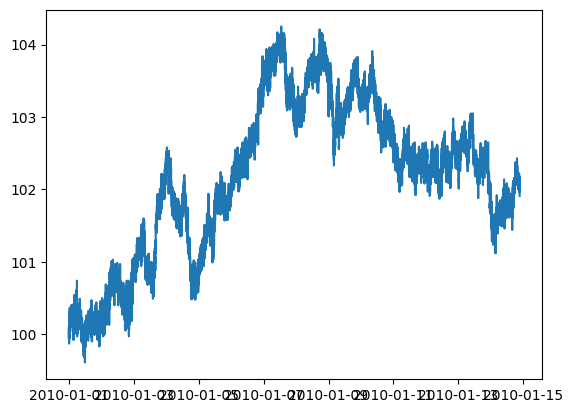

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from participants import simulate, prepare_data

# Run the simulation and prepare the data
n = 200_000
timestamped_data = simulate(decisions=n, seed=2)
ohlcv = prepare_data(timestamped_data, verbose=False)
plt.plot(ohlcv["close"])
plt.show()
ohlcv = ohlcv.reset_index()

In [173]:
X = ohlcv

# Create the target y and shift it by -1 minute.
# The target is the next minutes return direction
X['y'] = ohlcv['close'].pct_change(1).shift(-1) > 0
X['y'] = X['y'].replace({True: 1, False: 0})

# Remove the created nan
X = X.dropna()


# Create more features
for i in ["open", "high", "low", "close", "volume", "n_trades"]:
    for t in [1, 5, 10, 20]:
        X[f"{i}_pct_{t}"] = X[i].pct_change(t)
        if t > 1:
            X[f"{i}_mean_{t}"] = X[i].rolling(t).mean()
            X[f"{i}_std_{t}"] = X[i].rolling(t).std()

# Replace inf values with nan
X = X.replace([np.inf, -np.inf], np.nan)
# Fill nans with last available value
X = X.ffill()
# Remove leading nans
X = X.dropna()


# Separate the features and target
# use X[['y']] to avoid conversion to Series
y = X[['y']] 
# Also remove timestamp because model cannot handle datetime input
X = X[[x for x in X.columns if x not in ['y', 'timestamp']]]
X, y

C:\Users\luca\AppData\Local\Temp\ipykernel_15684\3771998509.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['y'] = X['y'].replace({True: 1, False: 0})


(         open    high     low   close  volume  n_trades  open_pct_1  \
 20     100.04  100.19  100.04  100.19    0.00         0    0.000000   
 21     100.04  100.19  100.04  100.19  189.00         4    0.000000   
 22     100.12  100.19  100.12  100.19    1.00         2    0.000800   
 23     100.08  100.19   99.95  100.19   87.00         5   -0.000400   
 24      99.95   99.95   99.95   99.95    6.00         1   -0.001299   
 ...       ...     ...     ...     ...     ...       ...         ...   
 19995  102.10  102.10  101.92  101.92  161.00         9    0.000000   
 19996  101.92  101.92  101.92  101.92    0.00         0   -0.001763   
 19997  101.92  102.11  101.92  102.11   37.22         4    0.000000   
 19998  102.00  102.00  102.00  102.00    0.00         2    0.000785   
 19999  101.96  101.96  101.91  101.91  134.00         4   -0.000392   
 
        open_pct_5  open_mean_5  open_std_5  ...  n_trades_pct_1  \
 20       0.000100       99.988    0.076616  ...            -1.0  

In [174]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import xgboost as xgb

def run_model(choice="XGB"):
    # Initialize the Time Series cross-validator
    # Train size is expanding and 
    # Test size by default is n_samples // (n_splits + 1)
    tscv = TimeSeriesSplit(n_splits=5)

    scores = []

    # Use enumerate(..., 1) to make i start at 1
    for i, (train_index, test_index) in enumerate(tscv.split(X), 1):

        # Select the relevant indices using .iloc
        X_train = X.iloc[train_index] 
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # Scale the feature data
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Set the model
        if choice == "XGB":
            model = xgb.XGBClassifier(n_estimators=300, max_depth=3, seed=10)
        elif choice == "LR":
            model = LogisticRegression(random_state=10)
        elif choice == "RF":
            model = RandomForestClassifier(n_estimators=300, max_depth=3, random_state=10)
        else:
            raise ValueError(f"Unknown model choice: {choice}")
        
        # Train the model
        # values.ravel() is needed to avoid a warning
        model.fit(X_train, y_train.values.ravel())

        # Create the predictions. Slice to get the predictions for 1 (True)
        predicted_probabilities = model.predict_proba(X_test)[:, 1]
        # predicted_outcome = model.predict(X_test)

        # Evaluate
        roc_auc_test = roc_auc_score(y_test, predicted_probabilities)
        scores.append(roc_auc_test)
   
    return scores

model_scores = {}
for i in ["XGB", "LR", "RF"]:
    score = run_model(choice=i)
    model_scores[i] = score

c:\Users\luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

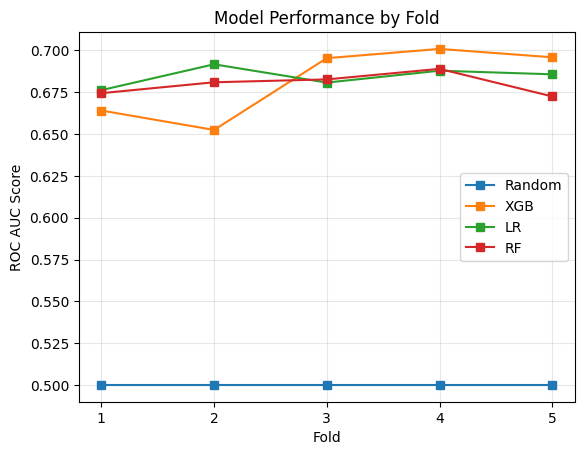

In [175]:
# Convert dictionary to df
model_scores_df = pd.DataFrame(model_scores)

# The ROC AUC of a random classifier is 0.5. This will be the baseline
model_scores_df['Random'] = [0.5] * 5
model_scores_df['fold'] = model_scores_df.index + 1

# Plot the model scores
for model in ["Random", "XGB", "LR", "RF"]:
    plt.plot(
        model_scores_df["fold"],
        model_scores_df[model],
        marker="s", label=model
    )

plt.title("Model Performance by Fold")
plt.xlabel("Fold")
plt.ylabel("ROC AUC Score")
plt.xticks(model_scores_df["fold"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

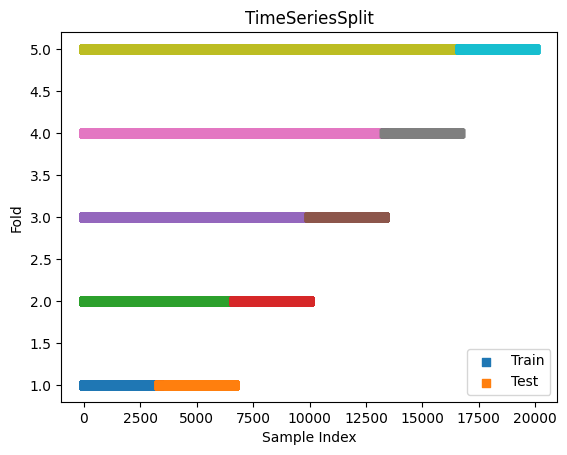

In [176]:
# Visualize the selected data
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    plt.scatter(train_idx, [fold] * len(train_idx), label="Train" if fold == 1 else "", marker="s")
    plt.scatter(test_idx, [fold] * len(test_idx), label="Test" if fold == 1 else "", marker="s")

plt.title("TimeSeriesSplit")
plt.xlabel("Sample Index")
plt.ylabel("Fold")
plt.legend()
plt.show()